In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams['font.family'] = 'DejaVu Sans'

sns.set_theme(style="whitegrid", palette="Set2")

In [ ]:
try:
    from IPython.display import display
except ImportError:
    display = print

In [ ]:
df_gd = pd.read_csv("/content/giao_dich.csv")
df_kh = pd.read_csv("/content/khach_hang_crm.csv")

In [ ]:
df_gd["ChiNhanh"] = df_gd["ChiNhanh"].fillna("Chưa xác định")
df_gd["GhiChu"] = df_gd["GhiChu"].fillna("")
df_gd["NgayGD"] = pd.to_datetime(df_gd["NgayGD"], dayfirst=True, format='mixed')
df_gd["Thang"] = df_gd["NgayGD"].dt.month
df_gd["Gio"] = df_gd["GioGD"].str.split(":").str[0].astype(int)
def phan_loai_gd(so_tien):
    if so_tien > 100_000_000:
        return "GD lớn (>100Tr)"
    elif so_tien > 10_000_000:
        return "GD vừa (10-100Tr)"
    else:
        return "GD nhỏ (<10Tr)"

df_gd["PhanLoaiGD"] = df_gd["SoTien"].apply(phan_loai_gd)

In [ ]:
df = pd.merge(df_gd, df_kh, on="MaKH", how="left")
df["NhomKH"] = df["NhomKH"].fillna("Chưa phân loại")
df["HoTen"] = df["HoTen"].fillna("Chưa xác định")
df["NgheNghiep"] = df["NgheNghiep"].fillna("Chưa xác định")

In [ ]:
#4. Phát Hiện Giao Dịch Bất Thường

mean_st = df["SoTien"].mean()
std_st = df["SoTien"].std()
nguong_3sigma = mean_st + 3 * std_st

df["BT_GiaTri"] = df["SoTien"] > nguong_3sigma

print("=" * 60)
print("PHÁT HIỆN BẤT THƯỜNG")
print("=" * 60)
print(f"  Ngưỡng 3σ: {nguong_3sigma:,.0f} VNĐ")
print(f"  GD giá trị bất thường: {df['BT_GiaTri'].sum()}")

if df["BT_GiaTri"].sum() > 0:
    print("\n  Chi tiết:")
    display(df[df["BT_GiaTri"]][["MaGD", "MaKH", "HoTen", "LoaiGD", "SoTien", "ChiNhanh"]])

# QUY TẮC 2: GD ngoài giờ hành chính
df["BT_ThoiGian"] = (df["Gio"] < 8) | (df["Gio"] >= 17)
print(f"\n  GD ngoài giờ HC (<8h, >=17h): {df['BT_ThoiGian'].sum()}")

# QUY TẮC 3: KH > 5 GD/ngày
gd_kh_ngay = df.groupby(["MaKH", "NgayGD"])["MaGD"].count().reset_index()
gd_kh_ngay.columns = ["MaKH", "NgayGD", "SoGD_Ngay"]
df = df.merge(gd_kh_ngay, on=["MaKH", "NgayGD"], how="left")
df["BT_TanSuat"] = df["SoGD_Ngay"] > 5
print(f"  KH giao dịch > 5 lần/ngày: {df['BT_TanSuat'].sum()}")

# Tổng hợp mức rủi ro
df["So_Co_BT"] = (
    df["BT_GiaTri"].astype(int) +
    df["BT_ThoiGian"].astype(int) +
    df["BT_TanSuat"].astype(int)
)

def phan_loai_rui_ro(so_co):
    if so_co >= 2:
        return "Rủi ro CAO"
    elif so_co == 1:
        return "Rủi ro TB"
    else:
        return "Bình thường"

df["MucDoRuiRo"] = df["So_Co_BT"].apply(phan_loai_rui_ro)

print(f"\n── Phân bổ mức độ rủi ro ──")
display(df["MucDoRuiRo"].value_counts())


PHÁT HIỆN BẤT THƯỜNG
  Ngưỡng 3σ: 599,734,241 VNĐ
  GD giá trị bất thường: 14

  Chi tiết:


,MaGD,MaKH,HoTen,LoaiGD,SoTien,ChiNhanh
26,GD000132,KH0184,Hồ Thùy Cường,Rút tiền,1262655145,Cần Thơ
62,GD000196,KH0186,Đỗ Hoàng Hải,Nạp tiền,976498065,Hải Phòng
68,GD000507,KH0185,Huỳnh Thị Sơn,Chuyển khoản,1796630570,Hà Nội
129,GD000624,KH0139,Lương Đức Hải,Chuyển khoản,978243923,Hà Nội
221,GD000898,KH0065,Lý Ngọc Hải,Mua ngoại tệ,1519164228,Thanh Hóa
235,GD000819,KH0070,Bùi Đức Tâm,Rút tiền,1933909908,Nghệ An
279,GD000964,KH0148,Lý Thị Dung,Thanh toán hóa đơn,1098412084,TP. Hồ Chí Minh
345,GD000687,KH0037,Lương Văn Vinh,Thanh toán hóa đơn,1161441447,Đà Nẵng
373,GD000580,KH0004,Dương Bảo Ích,Thanh toán hóa đơn,1904061811,Đồng Nai
402,GD000054,KH0098,Đặng Hoàng Quân,Chuyển khoản,1161999324,Khánh Hòa



  GD ngoài giờ HC (<8h, >=17h): 110
  KH giao dịch > 5 lần/ngày: 0

── Phân bổ mức độ rủi ro ──


,count
MucDoRuiRo,
Bình thường,897
Rủi ro TB,122
Rủi ro CAO,1


In [ ]:
#BÁO CÁO TỔNG QUAN
print("BÁO CÁO 1: TỔNG QUAN HOẠT ĐỘNG GIAO DỊCH")
print(f"  Tổng số giao dịch  : {len(df):,}")
print(f"  Tổng giá trị       : {df['SoTien'].sum():,.0f} VNĐ ({df['SoTien'].sum()/1e9:.1f} Tỷ)")
print(f"  Trung bình / GD    : {df['SoTien'].mean():,.0f} VNĐ")
print(f"  GD lớn nhất        : {df['SoTien'].max():,.0f} VNĐ")
print(f"  Số khách hàng      : {df['MaKH'].nunique()}")
print(f"  Số chi nhánh       : {df['ChiNhanh'].nunique()}")


BÁO CÁO 1: TỔNG QUAN HOẠT ĐỘNG GIAO DỊCH
  Tổng số giao dịch  : 1,020
  Tổng giá trị       : 114,308,517,822 VNĐ (114.3 Tỷ)
  Trung bình / GD    : 112,067,174 VNĐ
  GD lớn nhất        : 1,933,909,908 VNĐ
  Số khách hàng      : 198
  Số chi nhánh       : 29


In [ ]:
print("BÁO CÁO 2: TỔNG HỢP THEO CHI NHÁNH")
bc_cn = df.groupby("ChiNhanh").agg(
    So_GD=("MaGD", "count"),
    Tong_Tien=("SoTien", "sum"),
    TB_Tien=("SoTien", "mean"),
    So_KH=("MaKH", "nunique"),
).sort_values("Tong_Tien", ascending=False)

display(bc_cn)


BÁO CÁO 2: TỔNG HỢP THEO CHI NHÁNH


,So_GD,Tong_Tien,TB_Tien,So_KH
ChiNhanh,,,,
Khánh Hòa,101,13635261944,1.350026e+08,73
Thanh Hóa,113,13472352778,1.192244e+08,89
Đồng Nai,83,11325512473,1.364520e+08,68
Hà Nội,94,10888769265,1.158380e+08,73
Cần Thơ,98,10727823048,1.094676e+08,77
Nghệ An,94,10245664209,1.089964e+08,75
Hải Phòng,88,9749742322,1.107925e+08,70
Đà Nẵng,96,9193723595,9.576795e+07,72
TP. Hồ Chí Minh,84,9160837928,1.090576e+08,64


In [ ]:
# BÁO CÁO THEO THÁNG
print("BÁO CÁO 3: XU HƯỚNG THEO THÁNG")
bc_thang = df.groupby("Thang").agg(
    So_GD=("MaGD", "count"),
    Tong_Tien=("SoTien", "sum"),
).sort_index()

display(bc_thang)

BÁO CÁO 3: XU HƯỚNG THEO THÁNG


,So_GD,Tong_Tien
Thang,,
1,182,20592284989
2,157,17214234306
3,175,18838786464
4,175,17436037760
5,160,17489644105
6,171,22737530198


In [ ]:
#BÁO CÁO THEO NHÓM KHÁCH HÀNG
print("BÁO CÁO 4: PHÂN TÍCH THEO NHÓM KHÁCH HÀNG")

bc_nhom = df.groupby("NhomKH").agg(
    So_GD=("MaGD", "count"),
    Tong_Tien=("SoTien", "sum"),
    TB_Tien=("SoTien", "mean"),
    So_KH=("MaKH", "nunique"),
).sort_values("Tong_Tien", ascending=False)

display(bc_nhom)

BÁO CÁO 4: PHÂN TÍCH THEO NHÓM KHÁCH HÀNG


,So_GD,Tong_Tien,TB_Tien,So_KH
NhomKH,,,,
Doanh nghiệp lớn,275,32044320844,1.165248e+08,52
Cá nhân VIP,249,31807824034,1.277423e+08,49
Cá nhân thường,251,26006624965,1.036121e+08,51
Doanh nghiệp nhỏ,245,24449747979,9.979489e+07,46


In [ ]:
# BÁO CÁO THEO KÊNH GIAO DỊCH
print("BÁO CÁO 5: PHÂN TÍCH THEO KÊNH GIAO DỊCH")

bc_kenh = df.groupby("KenhGD").agg(
    So_GD=("MaGD", "count"),
    Tong_Tien=("SoTien", "sum"),
).sort_values("So_GD", ascending=False)

display(bc_kenh)

BÁO CÁO 5: PHÂN TÍCH THEO KÊNH GIAO DỊCH


,So_GD,Tong_Tien
KenhGD,,
Mobile App,204,22305373666
Internet Banking,198,22568405598
ATM,197,24260041177
POS,192,22014291334
Quầy giao dịch,186,18634046155


In [ ]:
#BÁO CÁO BẢNG CHÉO LOẠI GD × THÁNG
print("BÁO CÁO 6: BẢNG CHÉO LOẠI GD × THÁNG (Tỷ VNĐ)")

pivot_loai_thang = pd.pivot_table(
    df, values="SoTien", index="LoaiGD", columns="Thang",
    aggfunc="sum", fill_value=0
)
pivot_display = (pivot_loai_thang / 1e9).round(1)
display(pivot_display)


BÁO CÁO 6: BẢNG CHÉO LOẠI GD × THÁNG (Tỷ VNĐ)


Thang,1,2,3,4,5,6
LoaiGD,,,,,,
Chuyển khoản,5.5,2.9,2.7,4.1,2.3,4.6
Mua ngoại tệ,4.6,3.1,3.0,3.1,4.9,3.0
Nạp tiền,3.6,3.1,5.2,2.8,2.2,3.8
Rút tiền,3.2,3.1,3.1,3.0,2.5,7.6
Thanh toán hóa đơn,3.7,4.9,4.8,4.4,5.5,3.7


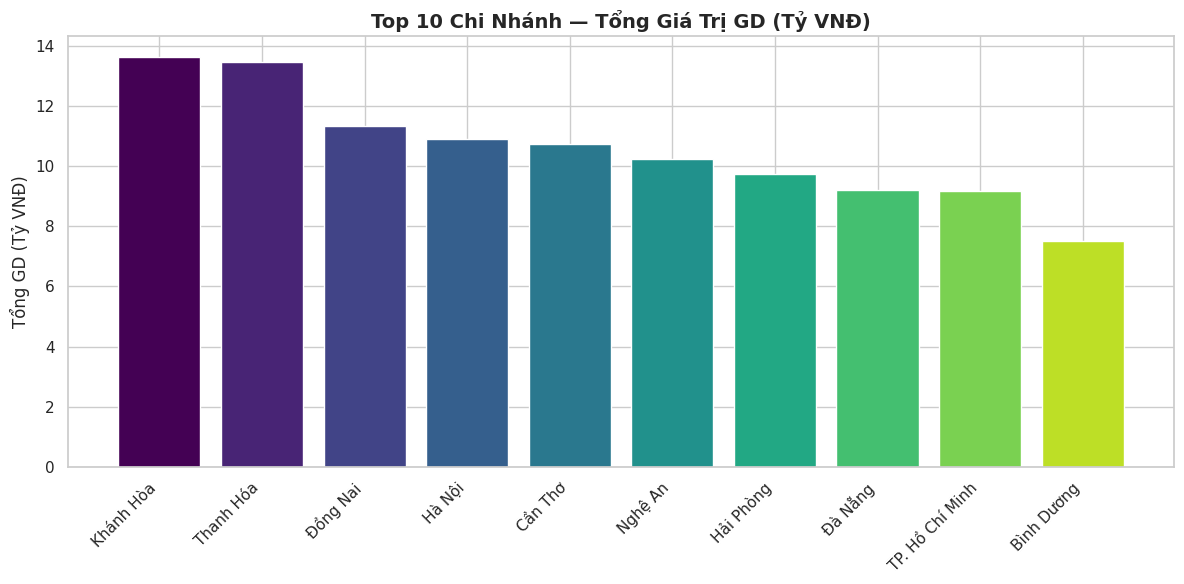

In [ ]:
# BIỂU ĐỒ 1: Top 10 Chi Nhánh
fig, ax = plt.subplots(figsize=(12, 6))
top10 = df.groupby("ChiNhanh")["SoTien"].sum().sort_values(ascending=False).head(10)
colors = plt.cm.viridis([i / len(top10) for i in range(len(top10))])
ax.bar(range(len(top10)), top10.values / 1e9, color=colors, edgecolor="white")
ax.set_xticks(range(len(top10)))
ax.set_xticklabels(top10.index, rotation=45, ha="right")
ax.set_title("Top 10 Chi Nhánh — Tổng Giá Trị GD (Tỷ VNĐ)", fontsize=14, fontweight="bold")
ax.set_ylabel("Tổng GD (Tỷ VNĐ)")
plt.tight_layout()
plt.savefig("bieu_do_top_chi_nhanh.png", dpi=200, bbox_inches="tight")
plt.show()

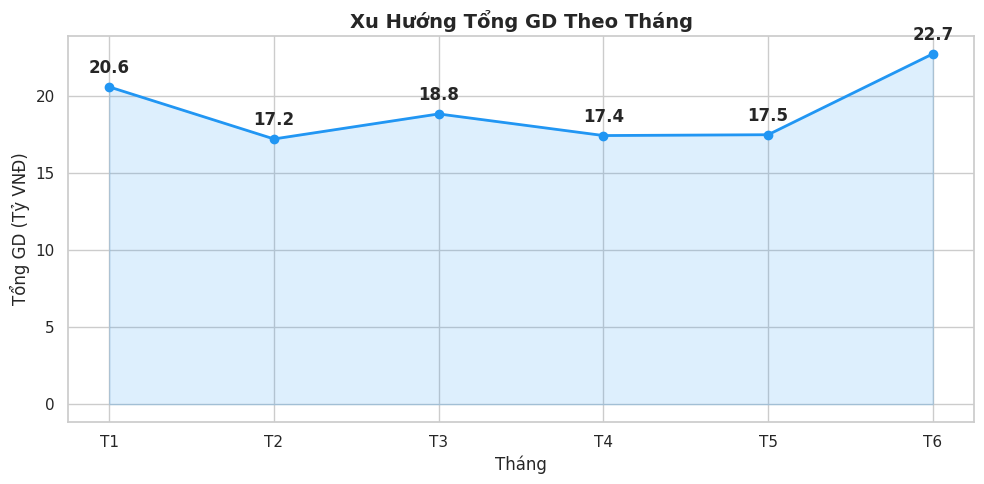

In [ ]:
#BIỂU ĐỒ 2: Xu Hướng Theo Tháng
fig, ax = plt.subplots(figsize=(10, 5))
trend = df.groupby("Thang")["SoTien"].sum()
ax.plot(trend.index, trend.values / 1e9, marker="o", color="#2196F3", linewidth=2)
ax.fill_between(trend.index, trend.values / 1e9, alpha=0.15, color="#2196F3")
ax.set_title("Xu Hướng Tổng GD Theo Tháng", fontsize=14, fontweight="bold")
ax.set_xlabel("Tháng")
ax.set_ylabel("Tổng GD (Tỷ VNĐ)")
ax.set_xticks(trend.index)
ax.set_xticklabels([f"T{t}" for t in trend.index])
for x, y in zip(trend.index, trend.values / 1e9):
    ax.annotate(f"{y:.1f}", (x, y), textcoords="offset points",
                xytext=(0, 10), ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("bieu_do_xu_huong_thang.png", dpi=200, bbox_inches="tight")
plt.show()

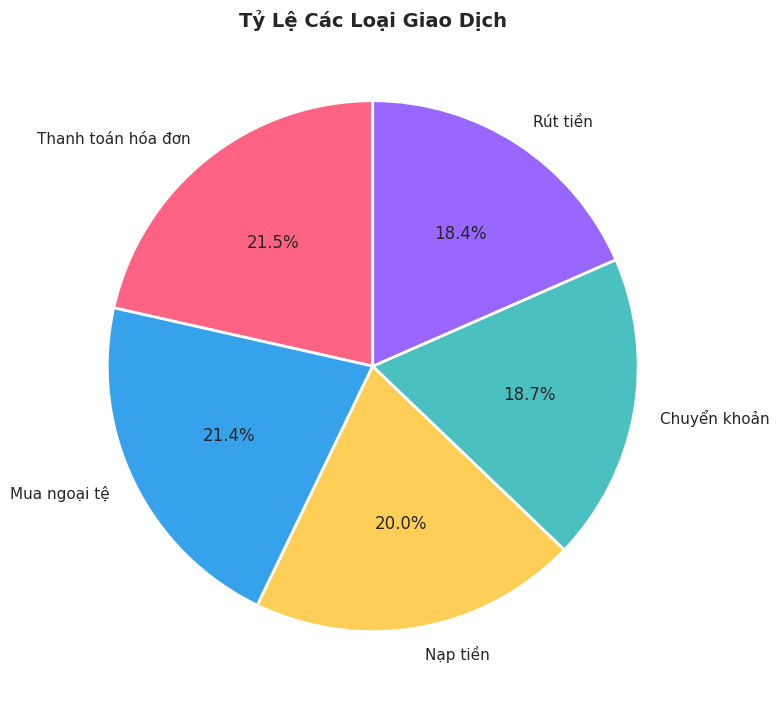

In [ ]:
#BIỂU ĐỒ 3: Tỷ Lệ Loại GD
fig, ax = plt.subplots(figsize=(8, 8))
ty_le = df["LoaiGD"].value_counts()
colors_pie = ["#FF6384", "#36A2EB", "#FFCE56", "#4BC0C0", "#9966FF"]
ax.pie(ty_le.values, labels=ty_le.index, autopct="%1.1f%%",
       colors=colors_pie[:len(ty_le)], startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 2})
ax.set_title("Tỷ Lệ Các Loại Giao Dịch", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("bieu_do_ty_le_loai_gd.png", dpi=200, bbox_inches="tight")
plt.show()

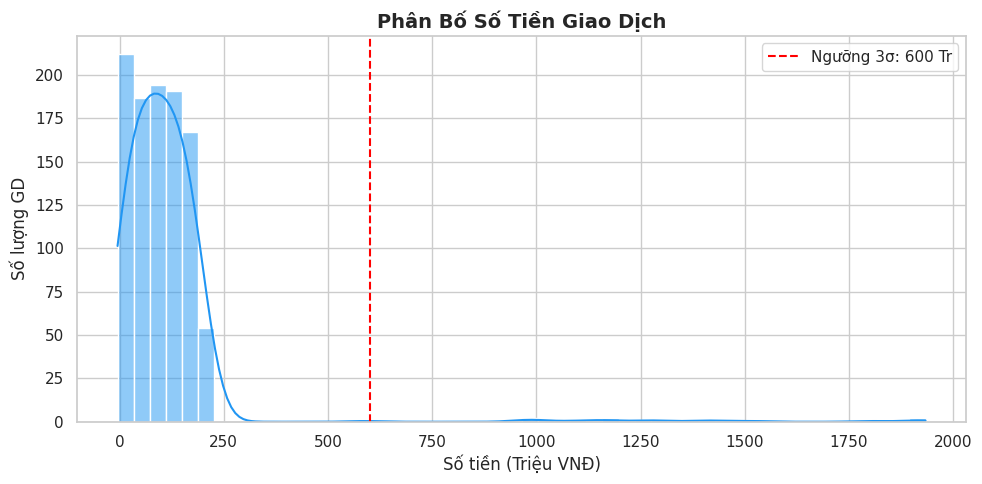

In [ ]:
# BIỂU ĐỒ 4: Phân Bố Số Tiền
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df["SoTien"] / 1e6, bins=50, kde=True, color="#2196F3", ax=ax)
ax.set_title("Phân Bố Số Tiền Giao Dịch", fontsize=14, fontweight="bold")
ax.set_xlabel("Số tiền (Triệu VNĐ)")
ax.set_ylabel("Số lượng GD")
ax.axvline(nguong_3sigma / 1e6, color="red", linestyle="--",
           label=f"Ngưỡng 3σ: {nguong_3sigma/1e6:.0f} Tr")
ax.legend()
plt.tight_layout()
plt.savefig("bieu_do_phan_bo_so_tien.png", dpi=200, bbox_inches="tight")
plt.show()



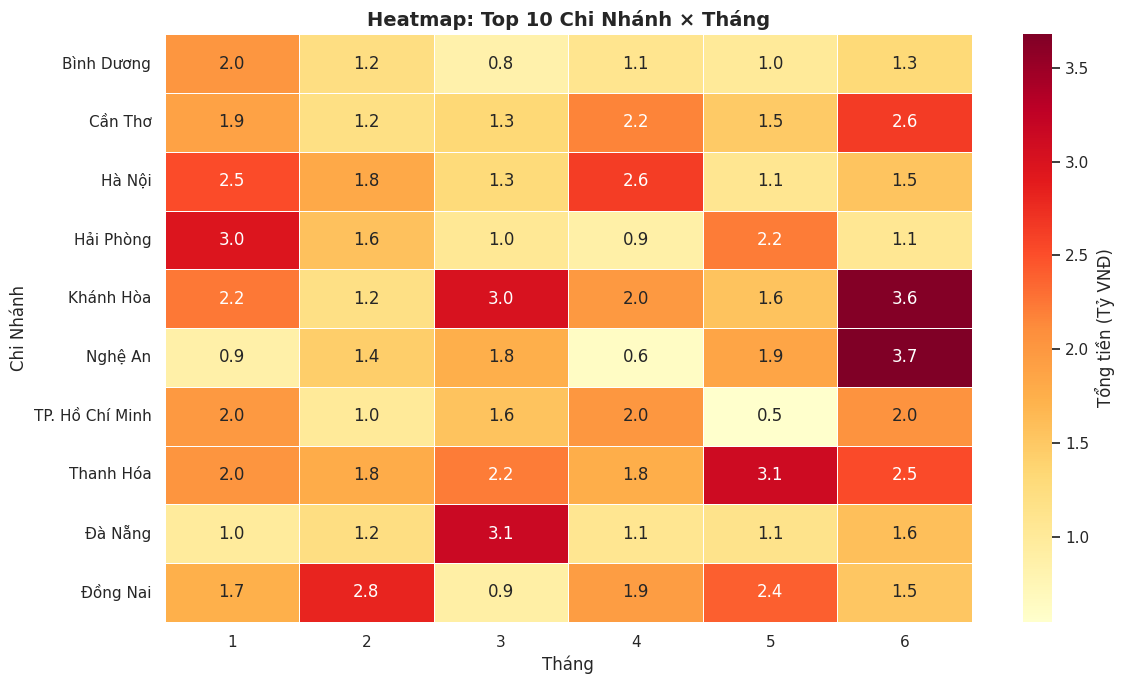

In [ ]:
#BIỂU ĐỒ 5: Heatmap Chi Nhánh × Tháng
fig, ax = plt.subplots(figsize=(12, 7))
top10_cn = df.groupby("ChiNhanh")["SoTien"].sum().sort_values(ascending=False).head(10).index
df_top10 = df[df["ChiNhanh"].isin(top10_cn)]
pivot_heat = pd.pivot_table(
    df_top10, values="SoTien", index="ChiNhanh", columns="Thang",
    aggfunc="sum", fill_value=0
)
sns.heatmap(pivot_heat / 1e9, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Tổng tiền (Tỷ VNĐ)"})
ax.set_title("Heatmap: Top 10 Chi Nhánh × Tháng", fontsize=14, fontweight="bold")
ax.set_xlabel("Tháng")
ax.set_ylabel("Chi Nhánh")
plt.tight_layout()
plt.savefig("bieu_do_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()


/tmp/ipykernel_1259/2799835236.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="KenhGD", y="SoTien", palette="Set2", ax=ax)


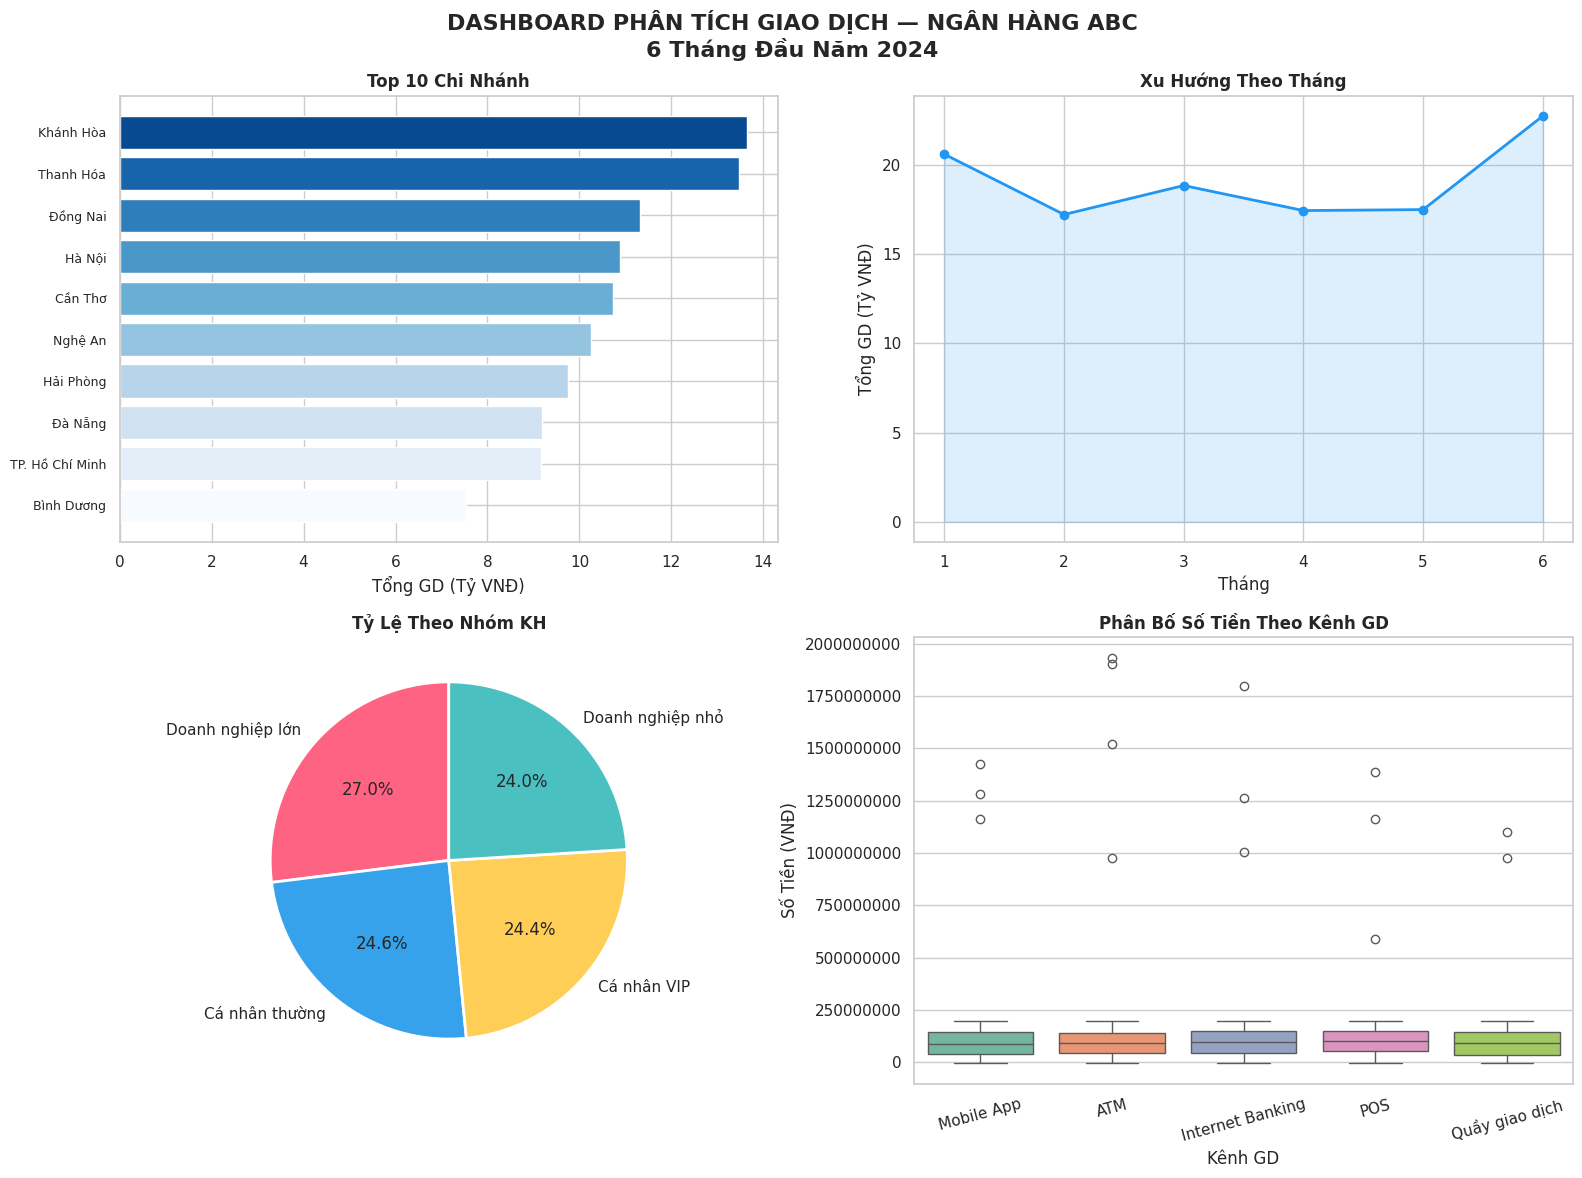

In [ ]:
#DASHBOARD 2×2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("DASHBOARD PHÂN TÍCH GIAO DỊCH — NGÂN HÀNG ABC\n6 Tháng Đầu Năm 2024",
             fontsize=16, fontweight="bold")

# Ô 1: Bar Top 10 Chi nhánh
ax = axes[0, 0]
top10 = df.groupby("ChiNhanh")["SoTien"].sum().sort_values(ascending=True).tail(10)
ax.barh(range(len(top10)), top10.values / 1e9, color=plt.cm.Blues([i / len(top10) for i in range(len(top10))]))
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(top10.index, fontsize=9)
ax.set_xlabel("Tổng GD (Tỷ VNĐ)")
ax.set_title("Top 10 Chi Nhánh", fontweight="bold")

# Ô 2: Line Trend theo tháng
ax = axes[0, 1]
trend = df.groupby("Thang")["SoTien"].sum()
ax.plot(trend.index, trend.values / 1e9, marker="o", color="#2196F3", linewidth=2)
ax.fill_between(trend.index, trend.values / 1e9, alpha=0.15, color="#2196F3")
ax.set_xlabel("Tháng")
ax.set_ylabel("Tổng GD (Tỷ VNĐ)")
ax.set_title("Xu Hướng Theo Tháng", fontweight="bold")
ax.set_xticks(trend.index)

# Ô 3: Pie Nhóm KH
ax = axes[1, 0]
nhom = df["NhomKH"].value_counts()
ax.pie(nhom.values, labels=nhom.index, autopct="%1.1f%%",
       colors=["#FF6384", "#36A2EB", "#FFCE56", "#4BC0C0", "#9966FF"],
       startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
ax.set_title("Tỷ Lệ Theo Nhóm KH", fontweight="bold")

# Ô 4: Boxplot SoTien theo Kênh GD
ax = axes[1, 1]
sns.boxplot(data=df, x="KenhGD", y="SoTien", palette="Set2", ax=ax)
ax.set_title("Phân Bố Số Tiền Theo Kênh GD", fontweight="bold")
ax.set_xlabel("Kênh GD")
ax.set_ylabel("Số Tiền (VNĐ)")
ax.ticklabel_format(style="plain", axis="y")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("dashboard_tong_hop.png", dpi=300, bbox_inches="tight")
plt.show()

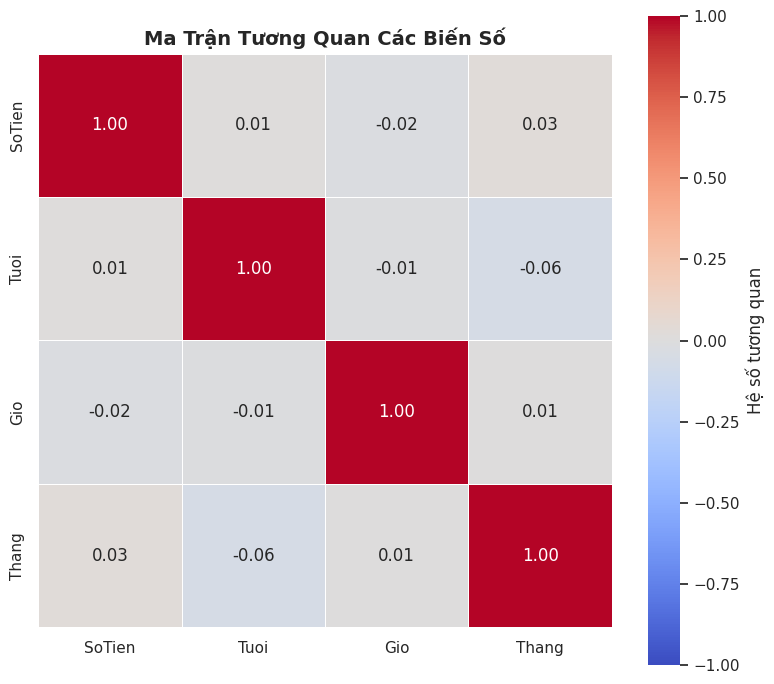

In [ ]:
#BIỂU ĐỒ 7: Ma Trận Tương Quan
fig, ax = plt.subplots(figsize=(8, 7))
cols_numeric = ["SoTien", "Tuoi", "Gio", "Thang"]
cols_available = [c for c in cols_numeric if c in df.columns]
corr_matrix = df[cols_available].corr()
mask = [[i < j for j in range(len(cols_available))] for i in range(len(cols_available))]
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
    linewidths=0.5, vmin=-1, vmax=1, center=0,
    square=True, ax=ax,
    cbar_kws={"label": "Hệ số tương quan"}
)
ax.set_title("Ma Trận Tương Quan Các Biến Số",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("bieu_do_tuong_quan.png", dpi=200, bbox_inches="tight")
plt.show()

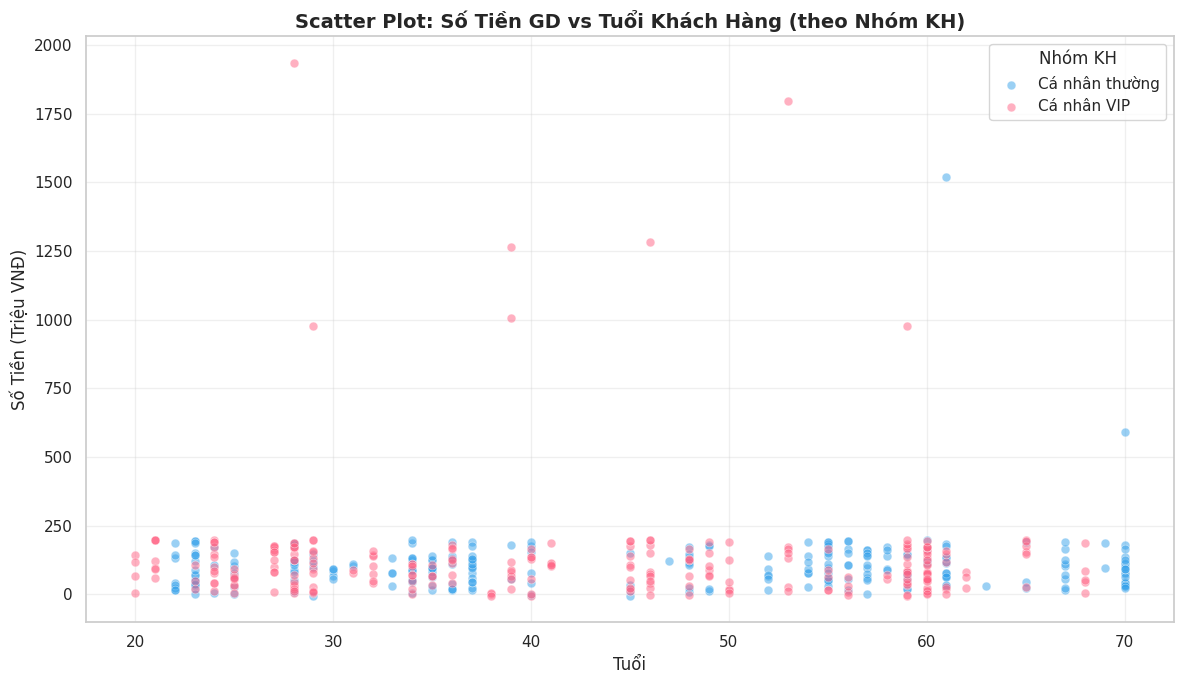

In [ ]:
# BIỂU ĐỒ 8: Số Tiền vs Tuổi Theo Nhóm KH
fig, ax = plt.subplots(figsize=(12, 7))
scatter_palette = {"Cá nhân thường": "#36A2EB", "Cá nhân VIP": "#FF6384",
                   "Doanh nghiệp": "#FFCE56", "Chưa phân loại": "#9966FF"}
for nhom, color in scatter_palette.items():
    subset = df[df["NhomKH"] == nhom]
    if len(subset) > 0:
        ax.scatter(
            subset["Tuoi"], subset["SoTien"] / 1e6,
            c=color, label=nhom, alpha=0.5, edgecolors="white",
            linewidth=0.5, s=40
        )
ax.set_title("Scatter Plot: Số Tiền GD vs Tuổi Khách Hàng (theo Nhóm KH)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Tuổi")
ax.set_ylabel("Số Tiền (Triệu VNĐ)")
ax.legend(title="Nhóm KH", loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("bieu_do_scatter_tuoi_sotien.png", dpi=200, bbox_inches="tight")
plt.show()

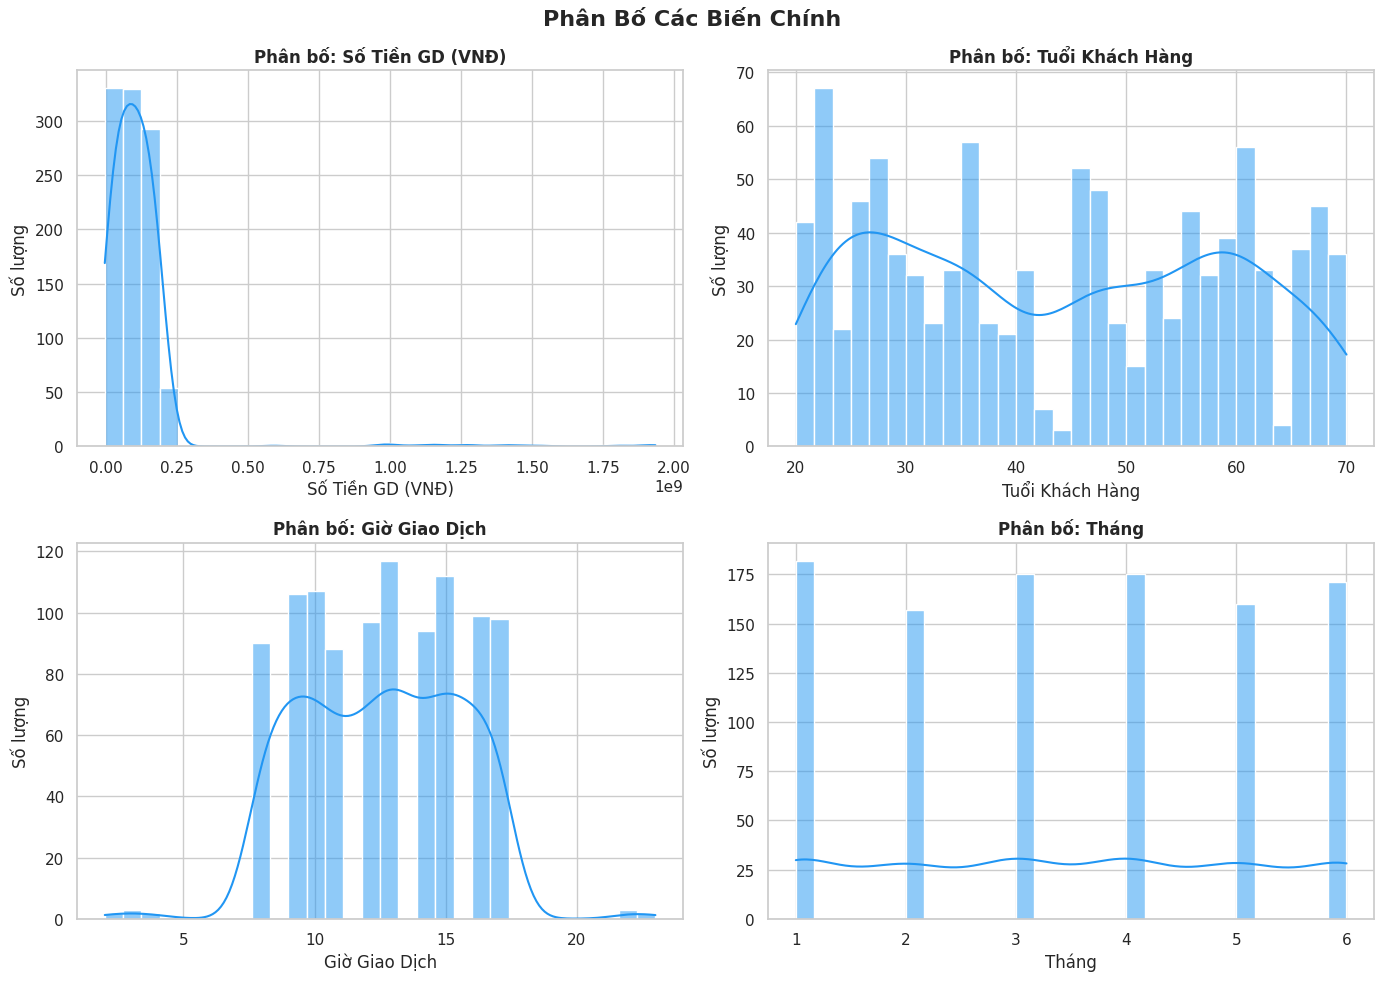

In [ ]:
# BIỂU ĐỒ 9: Phân Bố Các Biến Chính
vars_plot = {
    "SoTien": ("Số Tiền GD (VNĐ)", 1),
    "Tuoi": ("Tuổi Khách Hàng", 1),
    "Gio": ("Giờ Giao Dịch", 1),
    "Thang": ("Tháng", 1),
}
# Chỉ lấy các biến có trong DataFrame
vars_available = {k: v for k, v in vars_plot.items() if k in df.columns}
n_vars = len(vars_available)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Phân Bố Các Biến Chính", fontsize=16, fontweight="bold")

for idx, (col, (label, _)) in enumerate(vars_available.items()):
    ax = axes[idx // 2, idx % 2]
    sns.histplot(df[col].dropna(), bins=30, kde=True, color="#2196F3",
                 edgecolor="white", ax=ax)
    ax.set_title(f"Phân bố: {label}", fontweight="bold")
    ax.set_xlabel(label)
    ax.set_ylabel("Số lượng")

# Ẩn ô thừa nếu < 4 biến
for idx in range(n_vars, 4):
    axes[idx // 2, idx % 2].set_visible(False)

plt.tight_layout()
plt.savefig("bieu_do_phan_bo_bien.png", dpi=200, bbox_inches="tight")
plt.show()